# DC Motor, Locked Rotor Test, data processing

In [134]:
# Packages
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import seaborn as sns
import os

## First we need to load in the measurements.

In [135]:
# Folder name
CSV_folder_name = "CSV_files"
figure_folder_name = "figures"

# Load data from CSV file
file_name = "locked_rotor.csv" # CSV name
file_path = os.path.join(CSV_folder_name, file_name) # Generate file path
raw_df = pd.read_csv(file_path) # Read CSV file.

# Option to save data and figures ( True = Save data and figures, False = Don't save data and figures )
SAVE = False

## Next, we need to clculte the motors internal resistance

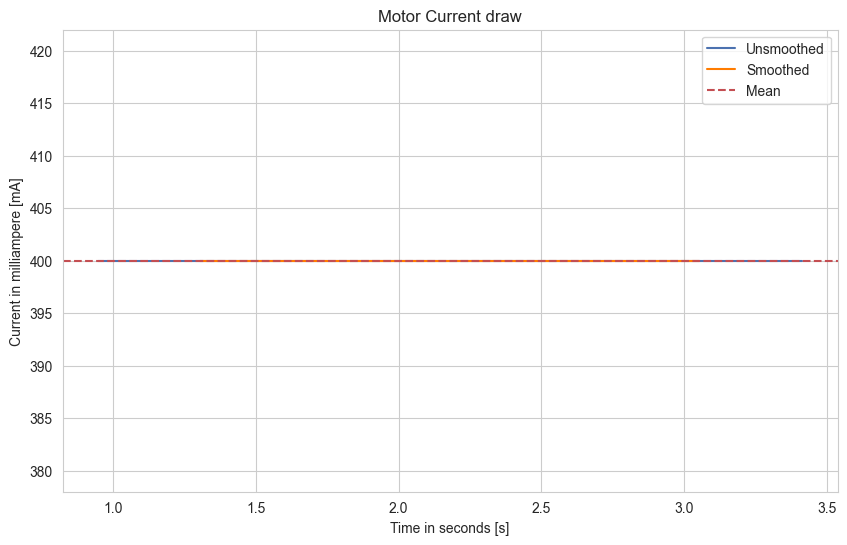

Mean Current: 0.4


In [136]:
# Select example sample from data set
sample = 8
data_type = 3 # (Angle = 0, V_bus = 1, V_shunt = 2, current = 3)

# Create new dataframe for rotor data, containing rotor position and time
current_data = pd.concat([raw_df.iloc[:, (5*sample + data_type)], raw_df.iloc[:, (5*sample + 4)]], axis=1)
current_data.columns = ['Current', 'Time']

# Apply the moving average using rolling method
window_size = 30
smoothed_df = current_data.rolling(window=window_size).mean()

# Drop rows with NaN values introduced by rolling method
smoothed_df.dropna(inplace=True)


# Plotting
# Set the style
sns.set_style("whitegrid")

# Accessing similar colors in seaborn's color palette
royal_blue = sns.color_palette('deep')[0]  # Similar to royal blue
bright_green = sns.color_palette('bright')[1]  # Higher contrast green color
coral_pink = sns.color_palette('deep')[3]  # Similar to coral pink

# Create Figure
plt.figure(figsize=(10, 6))

# Plot unsmoothed data with royal blue color
plt.plot(current_data['Time'], current_data['Current'], color=royal_blue, label='Unsmoothed')

# Plot smoothed data with brighter green color
plt.plot(smoothed_df['Time'], smoothed_df['Current'], color=bright_green, label='Smoothed')

# Plot horizontal line for the mean value with coral pink color
plt.axhline(y=smoothed_df['Current'].mean(), color=coral_pink, linestyle='--', label='Mean')

# Add labels and title
plt.xlabel('Time in seconds [s]')
plt.ylabel('Current in milliampere [mA]')
plt.title('Motor Current draw')

# Add legend
plt.legend()

# Save figure
file_name = "mean_current_draw.pdf" # Plot name
file_path = os.path.join(figure_folder_name, file_name) # Generate file path
if SAVE:
    plt.savefig(file_path, format='pdf')

# Show the plot
plt.show()

# Print the mean voltage
print("Mean Current:", (current_data['Current'].mean()/1000))

In [137]:
# Select example sample from data set
sample = 1
voltage_step = 1

# Create new dataframe for rotor data, containing rotor position and time
voltage_data = pd.concat([raw_df.iloc[:, (5*sample + 1)], raw_df.iloc[:, (5*sample + 2)], raw_df.iloc[:, (5*sample + 3)], raw_df.iloc[:, (5*sample + 4)]], axis=1)
voltage_data.columns = ['V_bus', 'V_shunt', "Current", "Time"]

# Change V_shunt from mV to V and Current from mA to A
voltage_data['V_shunt'] = voltage_data['V_shunt'] / 1000
voltage_data["Current"] = voltage_data["Current"] / 1000
print(voltage_data["V_bus"].mean())

# Calculate armature resistance.
voltage_data["Armature Resistance"] = ( voltage_step*sample - voltage_data['V_shunt'] ) / voltage_data['Current']
armature_resistance = voltage_data['Armature Resistance'].mean()

# Print estimated resitance
print("Estimated Armature Resistance = {:.2f}Ω.".format(armature_resistance))

3.478969072164949
Estimated Armature Resistance = 4.53Ω.


## Apply to entire dataset

In [138]:
# Create an empty DataFrame for motor constant
resistance_array = np.array([])
voltage_step = 1

# Iterating through every fifth column
for sample in range(0, len(raw_df.columns), 5):
    # Create new dataframe for rotor data, containing rotor position and time
    voltage_data = pd.concat([raw_df.iloc[:, (sample + 1)], raw_df.iloc[:, (sample + 2)], raw_df.iloc[:, (sample + 3)], raw_df.iloc[:, (sample + 4)]], axis=1)
    voltage_data.columns = ['V_bus', 'V_shunt', "Current", "Time"]

    # Change V_shunt from mV to V and Current from mA to A
    voltage_data['V_shunt'] = voltage_data['V_shunt'] / 1000
    voltage_data["Current"] = voltage_data["Current"] / 1000
    voltage_data["V_applied"] = voltage_step*(sample/5)
    print(voltage_data["V_applied"][0])

    # Calculate armature resistance.
    voltage_data["Armature Resistance"] = ( voltage_data["V_applied"] - voltage_data['V_shunt'] ) / voltage_data['Current']
    armature_resistance = voltage_data['Armature Resistance'].mean()
    resistance_array = np.append(resistance_array, armature_resistance)

print(resistance_array)
print(np.mean(resistance_array))

0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
[       -inf  4.52610495  5.18163947  7.74670088  9.9        12.4
 14.9        17.4        19.8972905  22.39696775 24.9        27.4
 29.9       ]
-inf
